In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import numpy as np
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from typing import Type, Callable, Any, List, Optional, Dict
import os
from tqdm.auto import tqdm

Device

In [2]:
if(torch.cuda.is_available()):
    device = 'cuda'
elif(torch.backends.mps.is_available()):
    device = 'mps'
else:
    device = 'cpu'

Load the data

In [3]:
data_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])


train_set = datasets.ImageFolder(root=r'C:\Users\chuyi\OneDrive\XMUM\ML code\database\data19065\train',
                                 transform=data_transform,
                                 target_transform=None)

test_set = datasets.ImageFolder(root=r'C:\Users\chuyi\OneDrive\XMUM\ML code\database\data19065\test',
                                 transform=data_transform,
                                 target_transform=None)


BATCHSIZE=32

train_dataloader = DataLoader(dataset=train_set, 
                              batch_size=BATCHSIZE, # how many samples per batch?
                              num_workers=8,#os.cpu_count(), # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_set, 
                             batch_size=BATCHSIZE,
                             num_workers=8,#os.cpu_count(), 
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x20066b69ca0>,
 <torch.utils.data.dataloader.DataLoader at 0x20068104fb0>)

In [4]:
# Get class names as a list
class_names = train_set.classes
class_names
# Can also get class names as a dict
class_dict = train_set.class_to_idx
class_dict
# Check the lengths
len(train_set), len(test_set)

(600, 200)

Define the training and evaluate fucntion

Train function

In [5]:
def train_step(model:nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer):
    
    model.train()
    train_loss, train_acc = 0.0, 0.0

    for batch,(x,y) in enumerate(dataloader):
        
        x,y = x.to(device),y.to(device)

        y_pred_logits = model(x)

        loss = loss_fn(y_pred_logits,y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred_logits)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model:nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:nn.Module):
    
    model.eval()
    test_loss, test_acc = 0.0, 0.0

    with torch.inference_mode():
        for batch, (x,y) in enumerate(dataloader):
            x,y = x.to(device),y.to(device)

            test_pred_logits = model(x)

            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [6]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        

        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [7]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

Define the basic blocks of ResNet

In [8]:
class Bottleneck(nn.Module):

    expansion = 4

    def __init__(self,in_channels,mid_channels,stride=1,downshape=None):
        super().__init__()


        #using  1,1 to reduct dim
        self.conv1 = nn.Conv2d(in_channels=in_channels,
                               out_channels=mid_channels,
                               kernel_size=1)
        self.bn1 = nn.BatchNorm2d(num_features=mid_channels)


        #using 3,3 to capture the feature
        self.conv2 = nn.Conv2d(in_channels=mid_channels,
                               out_channels=mid_channels,
                               kernel_size=3,
                               stride=stride,
                               padding=1
                               )
        self.bn2 = nn.BatchNorm2d(num_features=mid_channels)


        #using 1,1 to upward dim
        self.conv3 = nn.Conv2d(in_channels=mid_channels,
                               out_channels=mid_channels*self.expansion,
                               kernel_size=1)
        self.bn3 = nn.BatchNorm2d(num_features=mid_channels*self.expansion)
        

        self.relu = nn.ReLU()

        self.downshape = downshape


    def forward(self,x:torch.Tensor):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.conv3(x)
        x = self.bn3(x)

        if self.downshape is not None:
            identity = self.downshape(identity)

        x += identity
        x = self.relu(x)

        return x
    

In [9]:
class basic_block(nn.Module):
    def __init__(self,in_channels,mid_channels,stride,downshape=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channels,
                              out_channels=mid_channels,
                              kernel_size=3,
                              stride=stride,
                              padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=mid_channels)

        self.conv2 = nn.Conv2d(in_channels=mid_channels,
                               out_channels=mid_channels,
                               kernel_size=3,
                               padding=1)
        self.bn2 = nn.BatchNorm2d(num_features=mid_channels)

        self.relu = nn.ReLU()

        self.downshape = downshape


    def forward(self,x:torch.Tensor):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)


        if(self.downshape != None):
            identity = self.downshape(identity)
        
        x += identity

        x = self.relu(x)

        return x


Define the model of ResNet

In [10]:
class ResNet50_101_152(nn.Module):
    def __init__(self,in_channels:int,block: Type[Bottleneck], layers: List[int], num_class: int):       
        super().__init__()
        self.plain = 64

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels,
                               out_channels=self.plain,
                               kernel_size=7,
                               stride=2,
                               padding=3),
            nn.BatchNorm2d(num_features=self.plain),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3,stride=2,padding=1))
        
        self.conv2_x = self.make_layer(block,mid_channels=64,blocks=layers[0])
        self.conv3_x = self.make_layer(block,mid_channels=128,blocks=layers[1],stride=2) 
        self.conv4_x = self.make_layer(block,mid_channels=256,blocks=layers[2],stride=2)
        self.conv5_x = self.make_layer(block,mid_channels=512,blocks=layers[3],stride=2)


        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512*block.expansion,num_class)
        # 512 is the output of conv4_x in this model, also the output shape of
        # resnet-34, write in this way is to convenience the modify to resnet-43
        # if the code only used for res-50+, then can directly writte 2048
        # the number of final output channel
    def make_layer(self,block,mid_channels,blocks,stride=1):
        downshape = None
        if stride !=1 or self.plain !=mid_channels*block.expansion:
            downshape = nn.Sequential(
                nn.Conv2d(in_channels=self.plain,out_channels=mid_channels*block.expansion,
                          kernel_size=1,stride=stride),
                nn.BatchNorm2d(num_features=mid_channels*block.expansion)              
            )

        layers = []
        layers.append(block(in_channels=self.plain,mid_channels=mid_channels,stride=stride,downshape=downshape))
        self.plain = mid_channels*block.expansion

        for _ in range(1,blocks):
            layers.append(block(self.plain,mid_channels,stride=1,downshape=None))

        return nn.Sequential(*layers)



    def forward(self,x:torch.Tensor):
        x = self.conv1(x)

        x = self.conv2_x(x)
        x = self.conv3_x(x)
        x = self.conv4_x(x)
        x = self.conv5_x(x)

        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)

        return x

Set the model

In [11]:
res50 = [3,4,6,3]
res101 = [3,4,23,3]
res152 = [3,8,36,3]

In [12]:
resnet50 = ResNet50_101_152(in_channels=train_set[0][0].shape[0],
                            block=Bottleneck,layers=res50,
                            num_class=len(train_set.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=resnet50.parameters())


EPOCHS = 5

resnet50_results = train(model=resnet50,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=EPOCHS)





  0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    
    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

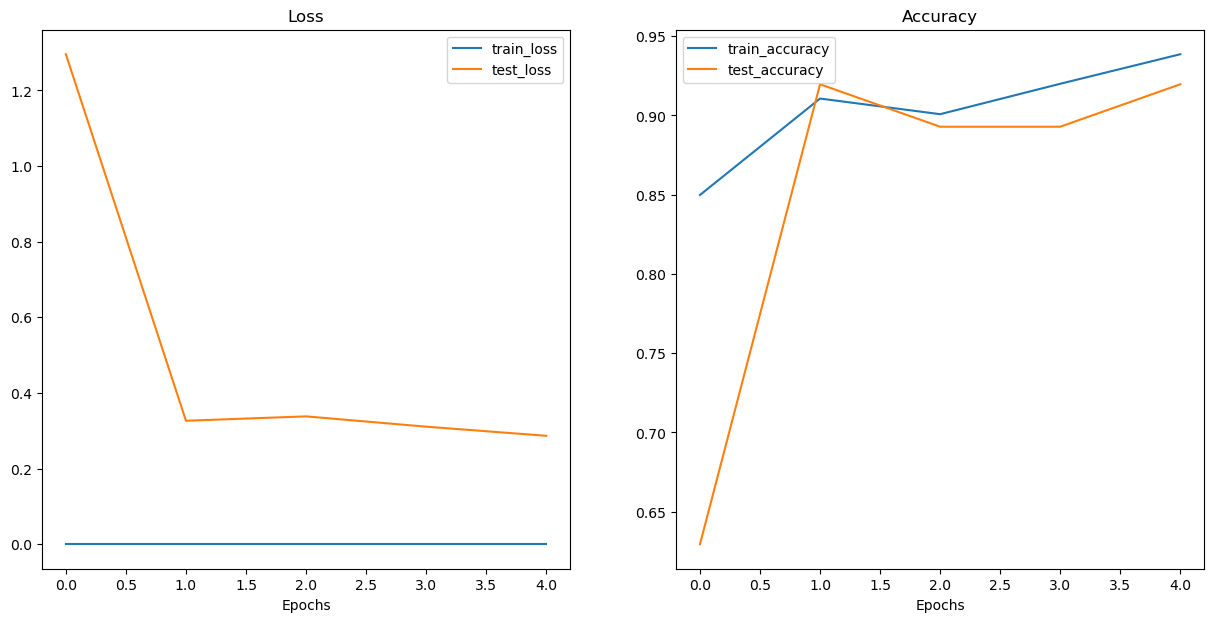

In [14]:
plot_loss_curves(resnet50_results)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9529412].


Image shape: torch.Size([224, 224, 3])


Text(0.5, 1.0, '1')

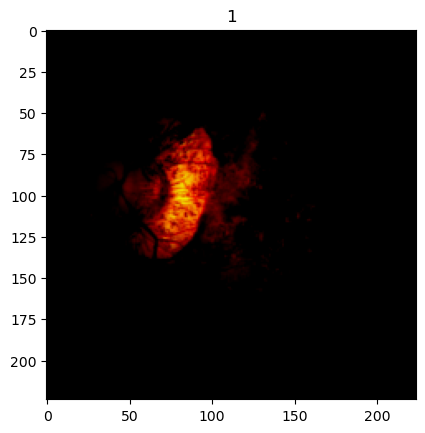

In [15]:
image, label = train_set[400]
image = image.permute(1,2,0)
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.37254906].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.94509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.92941177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7176471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.94509804].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid ra

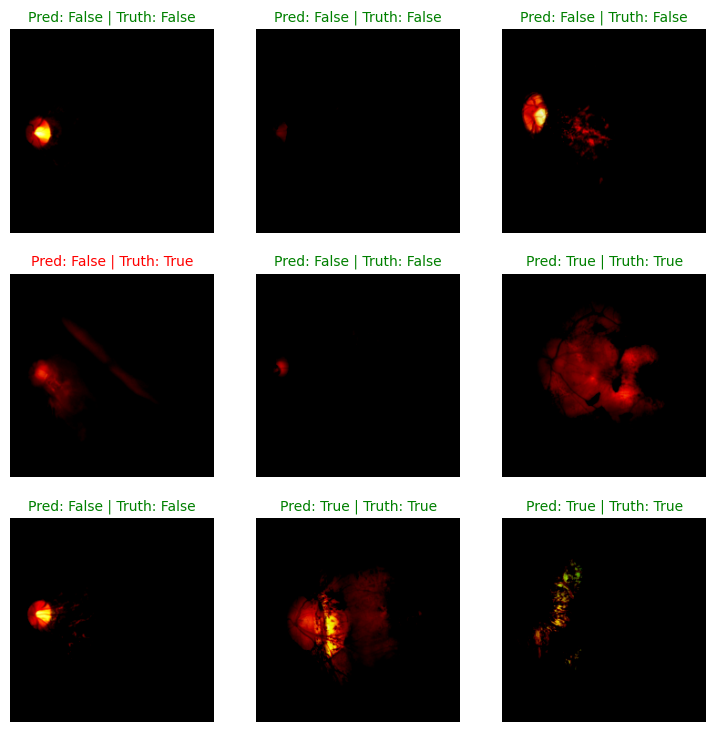

In [16]:
import random
test_samples = []
test_labels = []
for sample, label in random.sample(population=list(test_set), k=9):
    test_samples.append(sample)
    test_labels.append(label)

pred_probs= make_predictions(model=resnet50, 
                             data=test_samples)

pred_classes = pred_probs.argmax(dim=1)


# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create a subplot
    plt.subplot(nrows, ncols, i+1)

    sample = sample.permute(1,2,0)
    # Plot the target image
    plt.imshow(sample.squeeze())

    # Find the prediction label (in text form, e.g. "Sandal")
    pred_label = class_names[pred_classes[i]]

    # Get the truth label (in text form, e.g. "T-shirt")
    truth_label = class_names[test_labels[i]] 

    # Create the title text of the plot
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    # Check for equality and change title colour accordingly
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g") # green text if correct
    else:
        plt.title(title_text, fontsize=10, c="r") # red text if wrong
    plt.axis(False)